## Overview
This tutorial gives a complete overview of MiTo's core functionalities for mitochondrial single-cell lineage tracing (MT-scLT). The interested user is also encouraged to take a look at MiTo's companion pipeline, [nf-MiTo](https://github.com/andrecossa5/nf-MiTo), which automates this data workflow at scale. 

MiTo implements novel methods for MT-scLT (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165) for motivation and estensive benchmarks). While optimized for scRNA-seq data ([MAESTER](10.1038/s41587-022-01210-8) protocol), MiTo can flexibly process data from other scLT systems (e.g., RedeeM, scWGS and Cas9-based lineage recorders).  

This tutorial showcases the basic of MiTo APIs, which not only back up nf-MiTo lineage inference, but also enable interactive exploration of MT-scLT data straight after raw sequencing data pre-processing (see [nf-MiTo](https://github.com/andrecossa5/nf-MiTo) documentation). 

In particular, we will:

1. Load an AFM (AnnData format, output from nf-MiTo PREPROCESS)
2. Pre-process an AFM (i.e., cell and variant filtering, cell genotyping)
3. Compute pairwise cell-cell distances in the selected MT-SNV space 
4. Infer mitochondrial cell phylogenies 
5. Infer mitochondrial clones

On top of that, we will demonstrate how to use MiTo's built-in metrics to evaluate the quality of our data and inferences, and provide examples on how to use MiTo's powerful plotting library.

**N.B**: a properly configured MiTo environment is a necessary prerequisite for running this notebook. Follow [the dedicated section](https://andrecossa5.readthedocs.io/en/latest/installation.html) of this documentation to install MiTo and its dependencies on your computing environment.

## Dataset
This tutorial starts by downloding our test dataset from zenodo. Here, we will download the `MDA_clones` benchmarking dataset introduced in our recent [pre-print](https://doi.org/10.1101/2025.06.17.660165). This is a tri-modal dataset including simoultaneous profiling of MT-SNVs, gene expression, and lentiviral barcodes (i.e., our ground truth clonal labels) for n=558 quality controlled cells.

In [1]:
# Set WD
WD='/Users/IEO5505/Desktop/MI_TO/MiTo/scratch'  # Change this to your working directory
!cd $WD

# Download and unzip test data
!wget https://zenodo.org/records/17225334/files/data_test.tar.gz && \
tar -xzvf data_test.tar.gz && \
rm data_test.tar.gz 

--2025-10-01 16:29:44--  https://zenodo.org/records/17225334/files/data_test.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32419764 (31M) [application/octet-stream]
Saving to: ‘data_test.tar.gz’

data_test.tar.gz    100%[===================>]  30,92M  3,35MB/s    in 10s     

2025-10-01 16:29:55 (3,07 MB/s) - ‘data_test.tar.gz’ saved [32419764/32419764]

x data_test/
x data_test/coverage.txt.gz
x data_test/cells_meta.csv
x data_test/afm_unfiltered.h5ad


The `MDA_clones` dataset we have just downloaded includes:

1. `afm_unfiltered.h5ad`: unfiltered AFM (the output from nf-MiTo PREPROCESS, with `--pp_method` = `maegatk`)
2. `cells_meta.csv`: cell metadata, including minimal QC covariates and ground truth clonal labels (`GBC` column)
3. `coverage.txt.gz`: cell-by-MT-genome-position coverage table

In [8]:
!ls data_test

afm_unfiltered.h5ad cells_meta.csv      coverage.txt.gz


## Setup environment
We would also need to import all the necessary code, and to set up logging/visualization parameters:

In [9]:
import os
import logging
import numpy as np
import scanpy as sc
import mito as mt
import matplotlib.pyplot as plt
import plotting_utils as plu

# Logging
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

# Plotting parameters 
plu.set_rcParams({'figure.dpi':80})

# MiTo version and working directory
print(f"MiTo version: {mt.__version__}")
print(f"Working directory: {os.getcwd()}")

MiTo version: 0.0.9
Working directory: /Users/IEO5505/Desktop/MI_TO/MiTo/docs/source


## Load the Allelic Frequency Matrix (AFM)

We can now load our unfiltered AFM:


In [27]:
afm = sc.read('data_test/afm_unfiltered.h5ad')
print(afm)
print(f'scLT system: {afm.uns["scLT_system"]}')
print(f'Pre-processing pipeline adopted: {afm.uns["pp_method"]}')
print(f'Raw basecalls metrics: {afm.uns["raw_basecalls_metrics"]}')

AnnData object with n_obs × n_vars = 558 × 18846
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system'
    layers: 'AD', 'DP', 'qual', 'site_coverage'
scLT system: MAESTER
Pre-processing pipeline adopted: maegatk
Raw basecalls metrics: {'total_basecalls': 6559093, 'variant_basecalls': 192201, 'variant_basecalls_for_annot_cells': 192201}


As we can see, our `afm` is an `AnnData` object equipped with the following slots:

* `.obs`: cell metadata, with minimal QC covariates and ground truth clonal labels (i.e., `GBC` column) from lentiviral barcoding
* `.var`: variant (MT-SNVs) metadata (minimal MT-SNVs annotation is present in this unfiltered AFM, but it will be updated in the next pre-processing steps)
* `.uns`: dataset parameters (e.g., `pp_method` and `scLT_system`) and metrics (e.g., `raw_basecalls_metrics`) 
* `.layers`: 4 parallel cell x variant site sparse matrices

At this stage, this `afm.layers` include:

* `AD`: alternative allele total UMI counts
* `DP`: total UMI counts (DP can be >0 only for entries with AD>0)
* `qual`: average base calling quality 
* `site_coverage`: total UMI counts (site_coverage can be >0 even for entries with AD=0)

Our `.X` slot instead store "raw" Allelic Frequencies (AFs, i.e., AD / site coverage).

In [28]:
# Selection of cells (n=2, rows) and variants (n=3, columns) with most non-zero AF values
cells = (afm.X>0).sum(axis=1).A1.argsort()[::-1][:2]
variants = (afm.X>0).sum(axis=0).A1.argsort()[::-1][:3]

# Print out each layer subsection
print('AF')
print(afm[cells, variants].X.toarray())
print('AD')
print(afm[cells, variants].layers['AD'].toarray())
print('DP')
print(afm[cells, variants].layers['DP'].toarray())
print('qual')
print(afm[cells, variants].layers['qual'].toarray())
print('site_coverage')
print(afm[cells, variants].layers['site_coverage'].toarray())


AF
[[1.        0.9994376 1.       ]
 [1.        1.        1.       ]]
AD
[[3043 1777 1859]
 [2962 1446 2492]]
DP
[[3043 1778 1859]
 [2962 1446 2492]]
qual
[[45 45 45]
 [45 45 45]]
site_coverage
[[3043. 1778. 1859.]
 [2962. 1446. 2492.]]


We can now proceed with AFM pre-processing.

## AFM pre-processing
Proper AFM pre-processing is crucial for robust lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165)), and MiTo provides highly-optimized methods to handle this important analysis step.

### Cell Filtering
As mentioned, cells in the unfiltered AFM have already passed standard Gene Expression QC. However, we still need make sure that only cells with an high-quality MT-SNVs profile are included in downstream analysis. Specifically, here we are looking for cells with sufficiently high and evenly distributed coverage across the entire MT-genome (or MAESTER target sites, ~13k sites across the ~16kB MT-genome). To perform cell filtering, MiTo implements the `mt.pp.filter_cells` function:

In [29]:
afm = mt.pp.filter_cells(afm, cell_filter='filter2')
afm_raw = afm.copy()  # Keep a copy of the AFM with all MT-SNVs, for visualization purposes

2025-10-01 17:37:51,988 - INFO - scLT system: MAESTER
2025-10-01 17:37:52,042 - INFO - Filtered cells (i.e., median target MT-genome coverage >=25 and fraction covered sites >=0.75: 375


As we can see, the number of cells dropped from 558 to 375 (i.e., 37% of the starting cells were filtered out because they did not satisfy the necessary quality standards).

### MT-SNVs filtering
We can now proceed with next step: MT-SNVs filtering. To do this, we will use the `mt.pp.filter_afm` function:

In [30]:
afm = mt.pp.filter_afm(afm, filtering='MiTo')

2025-10-01 17:37:54,487 - INFO - Compute general dataset metrics...
2025-10-01 17:37:54,489 - INFO - Compute vars_df as in Weng et al., 2024
2025-10-01 17:37:54,826 - INFO - Filter MT-SNVs...
2025-10-01 17:37:54,827 - INFO - scLT_system: MAESTER
2025-10-01 17:37:54,827 - INFO - pp_method: maegatk
2025-10-01 17:37:54,827 - INFO - Feature selection method: MiTo
2025-10-01 17:37:54,827 - INFO - Original afm: n cells=375, n features=18494
2025-10-01 17:37:54,941 - INFO - afm after baseline filter: n cells=375, n features=4366
2025-10-01 17:37:54,941 - INFO - Re-annotate variants in afm
2025-10-01 17:37:55,023 - INFO - afm after MiTo filter: n cells=375, n features=34
2025-10-01 17:37:55,026 - INFO - Exclude 1 common SNVs events (dbSNP)
2025-10-01 17:37:55,048 - INFO - Exclude 0 common RNA editing events (REDIdb)
2025-10-01 17:37:55,059 - INFO - Assign MT-genotypes with MiTo method
2025-10-01 17:37:55,539 - INFO - n MT-SNVs genotyped with binomial mixtures: 10
2025-10-01 17:37:55,542 - INFO

As we can see from the printed logs, `mt.pp.filter_afm` performs different tasks to ensure only high-quality MT-SNVs (and the respective variant-bearing cells) are included for lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods).

In [31]:
print(afm)

AnnData object with n_obs × n_vars = 288 × 24
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt', 'mean_af', 'mean_cov', 'quality', 'n0', 'n1', 'n2', 'n5', 'n10', 'n50', 'Variant_CellN', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system', 'cell_filter', 'dataset_metrics', 'genotyping', 'distance_calculations', 'char_filter'
    layers: 'AD', 'DP', 'qual', 'site_coverage', 'bin'
    obsp: 'distances'


Our final pre-processed AFM include 288 high-quality cells and 24 MT-SNVs.
As shown, `mt.pp.filter_afm` internally calls `mt.pp.call_genotypes` and `mt.pp.compute_distances`, which assign binary genotypes to each cell/MT-SNV combination (the new `bin` layer in `afm.layers`) and compute cell-cell distances in this binarized feature space (with the default `weighted_jaccard` distance metric, see the new `distances` slot in `afm.obsp`). `mt.pp.filter_afm` also annotates variants (`afm.var`) and update AFM parameters and metrics in `afm.uns`. 

### Dimensionality reduction
Cell-cell distances can be used together with feature matrices to reduce the dimensionality of the dataset and visualize relevent patterns in the data. MiTo's `mt.pp.reduce_dimensions` performs this operation:

In [33]:
mt.pp.reduce_dimensions(afm, method='UMAP')
print(afm)

2025-10-01 17:38:26,222 - INFO - Use bin layer
2025-10-01 17:38:26,223 - INFO - Use precomputed distances


AnnData object with n_obs × n_vars = 288 × 24
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt', 'mean_af', 'mean_cov', 'quality', 'n0', 'n1', 'n2', 'n5', 'n10', 'n50', 'Variant_CellN', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system', 'cell_filter', 'dataset_metrics', 'genotyping', 'distance_calculations', 'char_filter'
    obsm: 'X_umap'
    layers: 'AD', 'DP', 'qual', 'site_coverage', 'bin'
    obsp: 'distances'


In this case, the default `UMAP` method is used to embed cells in a 2-dimensional space stored as the new `X_umap` entry in the `.obsm` slot of our AFM. We will visualize these embeddings later.

### (Optional) Filtered MT-SNVs space quality assessment

Pre-processing of our AFM is now done! 


Since this dataset comes with ground truth clonal labels, we can optionally check the quality of our MT-SNV space and its associated cell-cell distances. To do so, we first compute a k-nearest neighbor (kNN) graph of our cells (`mt.pp.kNN_graph` function), and then we use metrics that evaluate how well cell-cell distances can separate ground truth clonal populations (i.e., the categorical labels in the GBC column of `afm.obs`).

In [34]:
# Extract distance matrix and compute k-NN graph
D = afm.obsp['distances'].toarray()
idx, _, _ = mt.pp.kNN_graph(D=D, k=15, from_distances=True)

# Compute lineage quality metrics using ground truth GBC labels
auprc = mt.ut.distance_AUPRC(D, afm.obs['GBC'])
kbet_score = mt.ut.kbet(idx, afm.obs['GBC'])
nn_entropy = mt.ut.NN_entropy(idx, afm.obs['GBC'])
nn_purity = mt.ut.NN_purity(idx, afm.obs['GBC'])

# Print out metrics
print(f"- Distance AUPRC: {auprc:.3f}")
print(f"- kBET score: {kbet_score:.3f}")
print(f"- NN entropy: {nn_entropy:.3f}")
print(f"- NN purity: {nn_purity:.3f}")

- Distance AUPRC: 0.778
- kBET score: 0.483
- NN entropy: 1.078
- NN purity: 0.571


For details on these metrics choice and motivation, refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Lineage inference
After AFM pre-processing, lineage inference can start. First we will infer a mitochondrial cell phylogeny, and then, we will use this phylogeny to infer discrete mitochondrial clones. 

### Mitochondrial phylogenies
Phylogeny inference first, then. To accomplish this, we use the `mt.tl.build_tree` function, which implements several solvers from the [cassiopeia](https://github.com/YosefLab/Cassiopeia) package. Here, we use the the Unweighted Pair Group Method with Arithmetic Mean (UPGMA) method. Note that, on top of cassiopeia solvers, nf-MiTo support other tree-building algorithms (i.e., `mpboot` and `iqtree`, see [nf-MiTo](https://github.com/andrecossa5/nf-MiTo) for reference).

In [35]:
tree = mt.tl.build_tree(afm, precomputed=True, solver='UPMGA')

2025-10-01 17:38:48,213 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin
2025-10-01 17:38:48,214 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}
2025-10-01 17:38:48,217 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


### Mitochondrial clones

We can now use this mitochondrial phylogeny to infer discrete clonal labels. For this, we will use the `mt.tl.MiToTreeAnnotator` class and its `clonal_inference` method.

In [36]:
model = mt.tl.MiToTreeAnnotator(tree)
model.clonal_inference()

2025-10-01 17:38:52,657 - INFO - Retrieve cell assignment to tree clades
2025-10-01 17:38:52,691 - INFO - Compute mutations enrichment
2025-10-01 17:38:53,449 - INFO - Start Grid Search. n hyper-parameter combinations to explore: 36
Grid Search: 100%|██████████| 36/36 [00:09<00:00,  3.87it/s]
2025-10-01 17:39:02,745 - INFO - Hyper-params chosen: similarity_percentile=90, mut_enrichment_treshold=3, merging_treshold=0.5
2025-10-01 17:39:02,975 - INFO - Compute expansion pvalues
2025-10-01 17:39:02,977 - INFO - Estimate cell fitness scores


node_ranking: inferring ancestral fitness... done in  1.71 s
node_ranking: calculating alternative rankings... done in  0.11 s


2025-10-01 17:39:06,636 - INFO - MiTo clonal inference finished. 13.98 s


### (Optional) lineage inference evaluation

Evaluate the quality of our lineage inference using metrics that evaluate the correlation between tree topology and underlying character distances, the evolutionary pattern of MT-SNVs on tree branches, and the relationship between ground truth clones (GBC) and MiTo clones:

In [37]:
# Tree structure metrics
corr_distances, _ = mt.ut.calculate_corr_distances(tree)
ci_scores = mt.ut.CI(tree)
ri_scores = mt.ut.RI(tree)

print(f"Tree-structure metrics:")
print(f"- Distances correlation: {corr_distances:.3f}")
print(f"- Median CI: {np.median(ci_scores):.3f}")
print(f"- Median RI: {np.median(ri_scores):.3f}")

# Clonal assignment metrics
test_mask = tree.cell_meta['MiTo clone'].isna()
assigned_cells = ~test_mask
gbc_assigned = tree.cell_meta.loc[assigned_cells, 'GBC']
mito_assigned = tree.cell_meta.loc[assigned_cells, 'MiTo clone']
ari = mt.ut.custom_ARI(gbc_assigned, mito_assigned)
nmi = mt.ut.normalized_mutual_info_score(gbc_assigned, mito_assigned)

print(f"Clonal assignment metrics:")
print(f"- Adjusted Rand Index: {ari:.3f}")
print(f"- Normalized Mutual Information: {nmi:.3f}")

Tree-structure metrics:
- Distances correlation: 0.595
- Median CI: 0.292
- Median RI: 0.996
Clonal assignment metrics:
- Adjusted Rand Index: 0.950
- Normalized Mutual Information: 0.928


For more details on these metrics, please refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Visualization
We have pre-processed our AFM and leverage MT-SNVs to infer mitochondrial cell lineages. We can now create comprehensive visualizations to assess our results.

### MT-SNVs selection
First, we would like to visualize the properties of our filtered MT-SNVs callset.


We start by plotting the Allelic Frequency spectrum of MT-SNVs before and after AFM pre-processing:

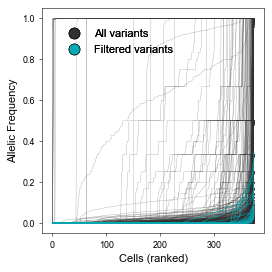

In [58]:
# Annotate vars in afm_raw
mt.pp.annotate_vars(afm_raw)

# Set colors
colors = {'All variants': '#303030', 'Filtered variants': '#05A8B3'}

# Plot allele frequency spectrum (before vs after filtering)
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.vars_AF_spectrum(afm_raw, ax=ax, color=colors['All variants'], alpha=.7, linewidth=.2)
mt.pl.vars_AF_spectrum(afm_raw[:,afm.var_names], ax=ax, color=colors['Filtered variants'], linewidth=.5, alpha=1)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We would also like to visualize the number of positive cells (+cells) vs the average number of UMIs supporting alternative allele basecalls across +cells, for each MT-SNV:

2025-10-01 17:58:11,383 - INFO - Re-annotate variants in afm
2025-10-01 17:58:11,798 - INFO - Re-annotate variants in afm


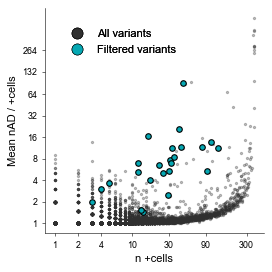

In [57]:
# Set xticks
xticks = [1, 2, 4, 10, 30, 90, 300, 1100]

# Plot number of cells vs mean alternative allele depth
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.plot_ncells_nAD(afm_raw, ax=ax, xticks=xticks, color='#303030', s=2, alpha=.3, label='All variants')
mt.pl.plot_ncells_nAD(afm, ax=ax, color='#05A8B3', xticks=xticks, s=5, alpha=1, markeredgecolor='k', label='Filtered variants')
plu.format_ax(ax=ax, ylabel='Mean nAD / +cells', xlabel='n +cells', reduced_spines=True)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We might also want to know where are these MT-SNVs distributed across the MT-genome

24


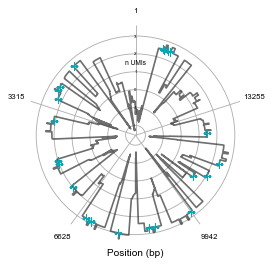

In [59]:
# Load coverage data
cov = mt.io.read_coverage(afm_raw, 'data_test/coverage.txt.gz', 'MDA_clones')

# Visualize MT genome coverage in polar coordinates, with MT-SNVs highlighted
fig, ax = plt.subplots(figsize=(3.5,3.5), subplot_kw={'projection': 'polar'})
mt.pl.MT_coverage_polar(
    cov, 
    var_subset=afm.var_names, ax=ax,
    yticks_size=4,
    kwargs_subset={'markersize': 8, 'c': '#05A8B3', 'label': 'Selected variants'}, 
    kwargs_main={'c': '#303030', 'linewidth': 1.5, 'alpha': .7, 'label': 'All positions'}
)
fig.tight_layout()
plt.show()

... which MT-gene harbour them

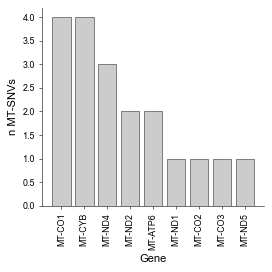

In [60]:
# Load MT-genes annotation
ref_df = mt.ut.load_mt_gene_annot()
df_plot = ref_df.query('mut in @afm.var_names')

# Plot variant distribution across MT genes
fig, ax = plt.subplots(figsize=(3.5,3.5))
plu.counts_plot(df_plot, 'Symbol', width=.8, ax=ax, color='#C0C0C0', edgecolor='k', with_label=False)
plu.format_ax(ax=ax, rotx=90, ylabel='n MT-SNVs', xlabel='Gene', reduced_spines=True)
fig.tight_layout()
plt.show()

... and which mutational signatures are they enriched for:

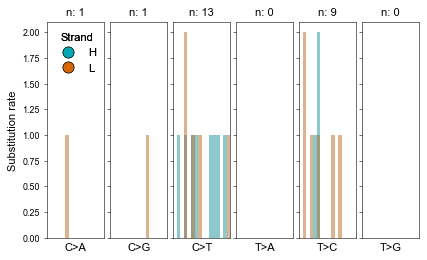

In [ ]:
fig = mt.pl.mut_profile(afm.var_names, figsize=(6,3.5))
fig.tight_layout()
plt.show()

We would also like to visualize our characters and cell-cell distances in clustered heatmaps:

2025-10-01 17:59:40,480 - INFO - Compute tree from precomputed cell-cell distances...
2025-10-01 17:59:40,481 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin
2025-10-01 17:59:40,482 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}
2025-10-01 17:59:40,483 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA
2025-10-01 17:59:40,613 - INFO - Retrieve cell assignment to tree clades
2025-10-01 17:59:40,626 - INFO - Compute mutations enrichment


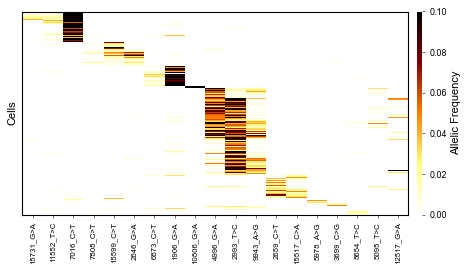

In [64]:
fig, ax = plt.subplots(figsize=(6,3.5))
mt.pl.heatmap_variants(afm, ax=ax, cmap='afmhot_r')
fig.tight_layout()
plt.show()

2025-10-01 18:06:04,930 - INFO - Compute tree from precomputed cell-cell distances...
2025-10-01 18:06:04,931 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin
2025-10-01 18:06:04,932 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}
2025-10-01 18:06:04,935 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


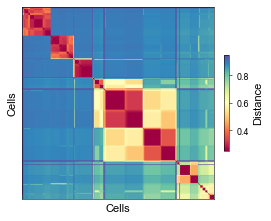

In [74]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
mt.pl.heatmap_distances(afm, ax=ax, cmap='Spectral')
fig.tight_layout()
plt.show()

### Lineage inference 
Before dealing with phylogeny inference diagnostics, we would also like to visualize if our ground-truth labels cluster in UMAP space.

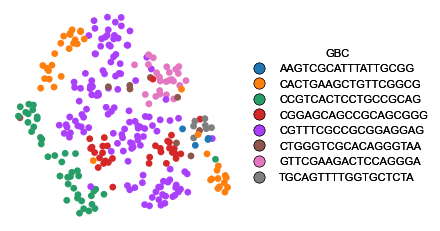

In [73]:
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = plu.create_palette(afm.obs, 'GBC', sc.pl.palettes.vega_10_scanpy)
mt.pl.draw_embedding(afm, feature='GBC', ax=ax, categorical_cmap=colors, legend=True, size=150)
plt.subplots_adjust(right=.7)
plt.show()

As we can see, to a great extent, lentiviral clones nicely cluster together.


Finally we would like to visualize our main downstream analysis product, our cell phylogeny and MiTo clones:

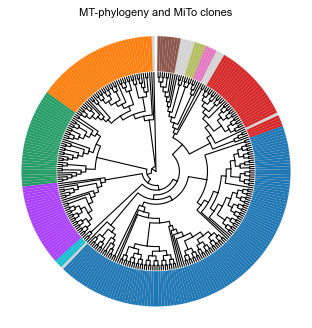

In [72]:
fig, ax = plt.subplots(figsize=(4, 4.2))
mt.pl.plot_tree(tree, ax=ax, features=['MiTo clone'], colorstrip_width=7.5)
ax.set_title('MT-phylogeny and MiTo clones')
fig.tight_layout()
plt.show()

## Summary
🎉 **Congratulations!** You've successfully gone through the basics of MiTo! 

## Outlook
More detailed tutorials starting from the nf-MiTo INFER output (bootstrapped cell phylogenies), will be soon available.
